In [123]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

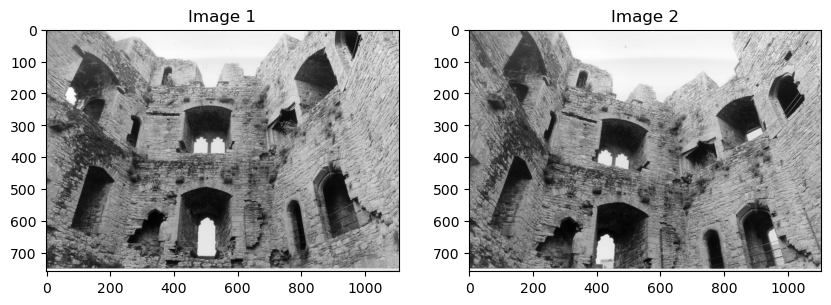

In [124]:
img1 = cv2.imread('Image1.jpg', cv2.IMREAD_GRAYSCALE)  # Première image
img2 = cv2.imread('Image2.jpg', cv2.IMREAD_GRAYSCALE)  # Deuxième image

# Afficher les images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title("Image 1")
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title("Image 2")
plt.show()

Etape 1:
Détection des caractéristiques des deux images avec ORB

In [125]:
orb = cv2.ORB_create(nfeatures=5000)  # Initialisation d'ORB

keypoints1 = orb.detect(img1,None)
keypoints2 = orb.detect(img2,None)
 

keypoints1, descriptors1 = orb.compute(img1, keypoints1)
keypoints2, descriptors2 = orb.compute(img2, keypoints2)

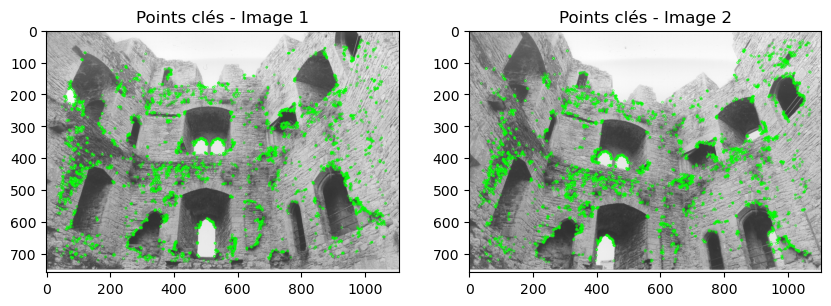

In [126]:
# Afficher les points clés sur la première image
img1_keypoints = cv2.drawKeypoints(img1, keypoints1, None, color=(0, 255, 0))
img2_keypoints = cv2.drawKeypoints(img2, keypoints2, None, color=(0, 255, 0))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img1_keypoints)
plt.title("Points clés - Image 1")
plt.subplot(1, 2, 2)
plt.imshow(img2_keypoints)
plt.title("Points clés - Image 2")
plt.show()

Étape 2 : Mise en correspondance avec BFMatcher et filtrage RANSAC

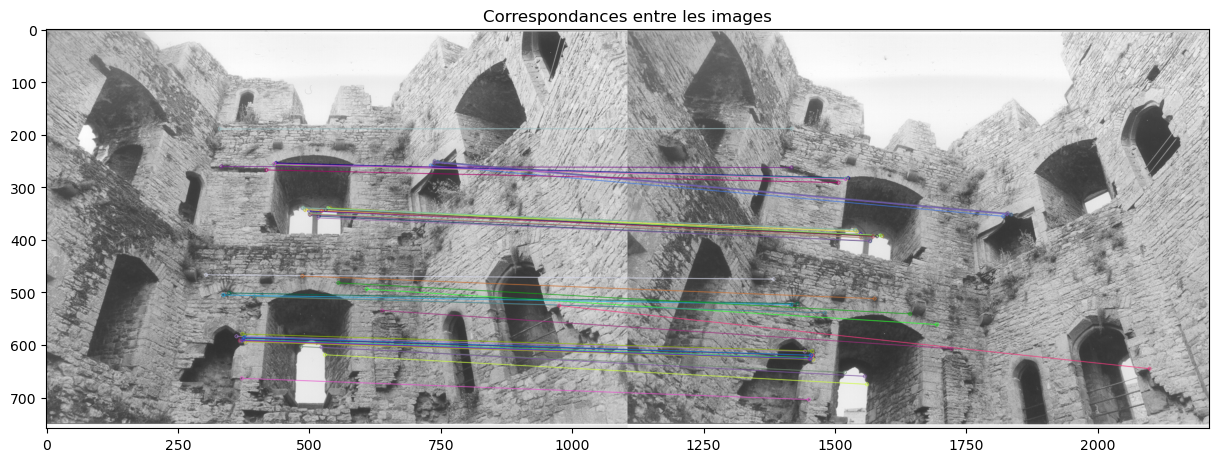

In [127]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# Afficher les correspondances
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:50], None, flags=2)
plt.figure(figsize=(15, 10))
plt.imshow(img_matches)
plt.title("Correspondances entre les images")
plt.show()

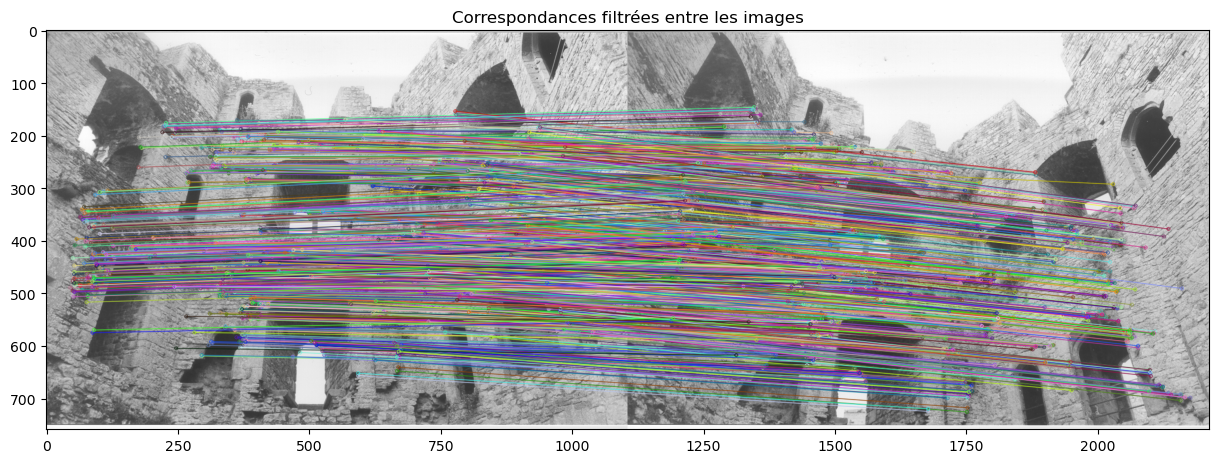

In [128]:
pts1 = np.float32([keypoints1[m.queryIdx].pt for m in matches])
pts2 = np.float32([keypoints2[m.trainIdx].pt for m in matches])

F, mask = cv2.findFundamentalMat(pts1, pts2, method=cv2.FM_RANSAC)

# Filtrer les correspondances avec le masque de RANSAC
pts1_filtered = pts1[mask.ravel() == 1]
pts2_filtered = pts2[mask.ravel() == 1]

# Afficher les correspondances filtrées
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, [matches[i] for i in range(len(matches)) if mask.ravel()[i] == 1], None, flags=2)
plt.figure(figsize=(15, 10))
plt.imshow(img_matches)
plt.title("Correspondances filtrées entre les images")
plt.show()

Etape 3: Matrice Essentielle 

In [129]:
K = np.array([[632.2, 0, 553], [0, 632.2, 379.5], [0, 0, 1]])
E, mask = cv2.findEssentialMat(pts1, pts2, K, method=cv2.RANSAC)
_, R, T, mask_pose = cv2.recoverPose(E, pts1_filtered, pts2_filtered, K)
print("Rotation :\n", R)
print("Translation :\n", T)

Rotation :
 [[ 0.95622674 -0.19623095 -0.21708024]
 [ 0.21735404  0.97297914  0.07790264]
 [ 0.19592764 -0.12167585  0.97304026]]
Translation :
 [[0.99598932]
 [0.0401846 ]
 [0.0799404 ]]


Etape 4: Triangulation et Reconstruction3D

In [133]:
# Triangulation
proj_matrix1 = np.hstack((np.eye(3), np.zeros((3, 1))))  
proj_matrix2 = np.hstack((R, T))  
points_4d_hom = cv2.triangulatePoints(K @ proj_matrix1, K @ proj_matrix2, pts1_filtered.T, pts2_filtered.T)


points_3d = points_4d_hom[:3] / points_4d_hom[3]


fig = go.Figure()


fig.add_trace(go.Scatter3d(
    x=points_3d[0],  
    y=points_3d[1],  
    z=points_3d[2],  
    mode='markers',
    marker=dict(
        size=2,
        color=points_3d[2],  
        colorscale='Viridis',  
        opacity=0.8
    )
))


fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    title="Points reconstruits en 3D",
    margin=dict(l=0, r=0, b=0, t=40)  
)


fig.show()